In [4]:
# input
import pandas as pd
import argparse
import numpy as np
import seaborn as sns
import scipy as sc

In [5]:
def get_peaks(data,bin_size_kb=2, comp_flanksize_kb=50, fold_thresh=5):
    scaff_l = list(set(data.Scaffold))
    peak = []
    nopeak = []
    
    for scaff in scaff_l:
        onekbfile = data.loc[data.Scaffold==scaff].reset_index()
        
        for i, bin in onekbfile.iterrows():
            #print(i)
            #print(scaff)
            #print(bin.Start_bp)
            #print(onekbfile)
            #print(onekbfile.iloc[i:i+bin_size_kb-1])
            peak_mean_rho = onekbfile.iloc[i:i+bin_size_kb-1].Rho_kb.mean()
            #print(peak_mean_rho)

            if i == onekbfile.index.max():
                peak_end = onekbfile.iloc[i,].End_bp
            else:
                try:
                    peak_end = onekbfile.iloc[i+1,].End_bp
                except IndexError:
                    #print(onekbfile.index.max())
                    #print(i)
                    #print(bin)
                    peak_end = onekbfile.iloc[i,].End_bp
                    raise IndexError
                    
                    
            flank_start = i-50
            if flank_start<0: # make sure we dont overshoot the scaffold boundary
                flank_start=0
    
            flank_stop = i+bin_size_kb-1+50
            if flank_stop>onekbfile.index.max(): # make sure we dont overshoot the scaffold boundary
                flank_stop=onekbfile.index.max()

            flank_mean_rho = onekbfile.iloc[flank_start:flank_stop].Rho_kb.mean()
            #print(scaff)
            #print(bin.Start_bp)
            #print(peak_end)
            #print(peak_mean_rho)
            #print(flank_mean_rho)
            #print(peak_mean_rho/flank_mean_rho)
            fold_diff = (peak_mean_rho/flank_mean_rho)
            if fold_diff>fold_thresh:
                #print("PEAK")
                peak.append([scaff, bin.Start_bp, peak_end, True, fold_diff, peak_mean_rho, flank_mean_rho])
            else:
                nopeak.append([scaff, bin.Start_bp, peak_end, False, fold_diff, peak_mean_rho, flank_mean_rho])
        #    else: 
        #        peak.append('False')
    return peak, nopeak
        
    

In [6]:
peaks = pd.read_csv('/home/tilman/termites/csec_prdm9/data/20231204_Csec_5fold_peaks.bed', sep='\t', header=None)

In [7]:
nopeaks = pd.read_csv('/home/tilman/termites/csec_prdm9/data/20231205_Csec_5fold_nopeaks_all.tsv', sep='\t', header=0)

In [14]:
peaks.columns = ["scaffold", "bin_Start_bp", "bin_Stop_bp", "peak", "fold_diff", "peak_mean_rho", "flank_mean_rho"]
nopeaks.columns = ["scaffold", "bin_Start_bp", "bin_Stop_bp", "peak", "fold_diff", "peak_mean_rho", "flank_mean_rho"]

In [59]:
nopeaks.peak = [False for i in nopeaks.peak ]

,scaffold,bin_Start_bp,bin_Stop_bp,peak,fold_diff,peak_mean_rho,flank_mean_rho
0,NEVH01020951.1,15000,17000,True,9.032687,52.22450,5.781724
1,NEVH01020951.1,45000,47000,True,5.026891,29.83070,5.934225
2,NEVH01020951.1,46000,48000,True,6.787247,39.93290,5.883520
3,NEVH01020951.1,47000,49000,True,6.124361,35.76020,5.839009
4,NEVH01020951.1,155000,157000,True,9.060526,92.35410,10.193017
...,...,...,...,...,...,...,...
945134,NEVH01005895.1,59000,61000,False,1.568888,16.19460,10.322341
945135,NEVH01005895.1,60000,62000,False,1.543161,16.19460,10.494430
945136,NEVH01005895.1,61000,63000,False,1.517315,16.19460,10.673198
945137,NEVH01005895.1,62000,63000,False,1.549108,16.10530,10.396500


In [60]:
allpeaks = pd.concat([peaks, nopeaks])

In [61]:
kb2_CPG = pd.read_csv('../../Csec_cpg_oe_2kbwin.csv', index_col=0)

In [62]:
kb2_CPG

,scaffold,cpg_oe,start,stop
0,NW_019718022.1,0.197302,0.0,2000.0
1,NW_019718022.1,0.345112,2000.0,4000.0
2,NW_019718022.1,0.568524,4000.0,6000.0
3,NW_019718022.1,0.253839,6000.0,8000.0
4,NW_019718022.1,0.939022,8000.0,10000.0
...,...,...,...,...
552168,NW_019773510.1,0.115327,1000.0,2000.0
552169,NW_019773511.1,0.744470,0.0,1000.0
552170,NW_019773511.1,0.656844,1000.0,3000.0
552171,NW_019773512.1,0.623744,0.0,2000.0


In [63]:
tdict = {}
translate_df = pd.read_csv("/home/tilman/termites/csec_prdm9/data/GCF_002891405.2_Csec_1.0_assembly_report.txt", comment="#", sep='\t', header=None)
for i, k in translate_df.iterrows():
    tdict[k[6]]=k[4]

In [64]:
kb2_CPG['scaffold'] = [tdict[i] for i in kb2_CPG['scaffold']]

In [65]:
kb2_CPG_HS = kb2_CPG.merge(allpeaks, left_on=['scaffold', 'start'], right_on=['scaffold','bin_Start_bp'])

<Axes: xlabel='peak', ylabel='cpg_oe'>

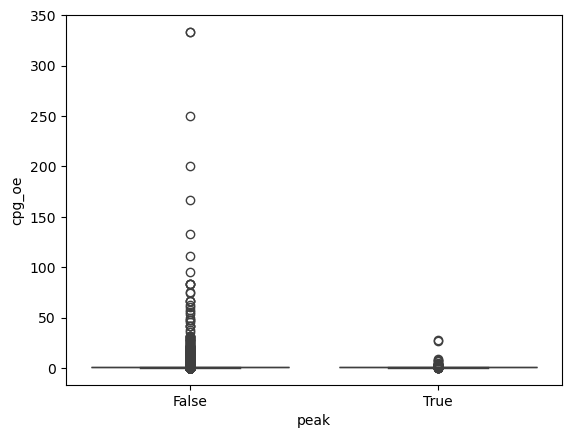

In [66]:
sns.boxplot(x='peak', y='cpg_oe', data=kb2_CPG_HS)

In [67]:
sc.stats.ttest_ind(a=kb2_CPG_HS.loc[kb2_CPG_HS.peak==True].cpg_oe, b=kb2_CPG_HS.loc[kb2_CPG_HS.peak==False].cpg_oe, nan_policy='omit')

TtestResult(statistic=-1.2119905822810964, pvalue=0.22551656509635334, df=494226.0)

In [69]:
kb2_CPG_HS.loc[kb2_CPG_HS.peak==True].cpg_oe.mean()

0.7152021034026941

In [68]:
kb2_CPG_HS.loc[kb2_CPG_HS.peak==False].cpg_oe.mean()

0.7243609617661734

,scaffold,cpg_oe,start,stop,bin_Start_bp,bin_Stop_bp,peak,fold_diff,peak_mean_rho,flank_mean_rho
0,NEVH01000001.1,0.197302,0.0,2000.0,0,2000,False,0.256573,0.651010,2.537325
1,NEVH01000001.1,0.345112,2000.0,4000.0,2000,4000,False,0.247279,0.603890,2.442142
2,NEVH01000001.1,0.568524,4000.0,6000.0,4000,6000,False,0.177894,0.420231,2.362255
3,NEVH01000001.1,0.253839,6000.0,8000.0,6000,8000,False,0.176231,0.405191,2.299199
4,NEVH01000001.1,0.939022,8000.0,10000.0,8000,10000,False,0.181878,0.404430,2.223637
...,...,...,...,...,...,...,...,...,...,...
495859,NEVH01055488.1,0.248397,1000.0,2000.0,1000,2000,False,1.000000,0.978070,0.978070
495860,NEVH01055490.1,0.744470,0.0,1000.0,0,2000,False,1.000000,1.477180,1.477180
495861,NEVH01055490.1,0.656844,1000.0,3000.0,1000,2000,False,1.139699,1.683540,1.477180
495862,NEVH01055491.1,0.623744,0.0,2000.0,0,2000,False,1.537937,0.022212,0.014442
